# GCAP3226 Week 4 — In-class exercise (5%)

**Individual.** Three tasks + submit (Commit & Push → Moodle GitHub URL).

| Task | Do this |
|------|---------|
| **1** | Percentage change by A&E triage; largest fall / rise; triage 4+5 combined |
| **2** | Grouped bar chart: H1 2025 vs H1 2026 attendances by triage (10 bars) + numbers / percentage change |
| **3** | Short write-up: one supporting point + one gap for the A&E claim |


## Setup

Run the next cell. Data: `w4_ae_triage_h1.csv` (**H1** 2025 vs **H1** 2026 attendances by triage).

**H1** = first half of the year (usually **1 January – 30 June**).

**AI:** `Cmd+I` / `Ctrl+I` on a code cell → implement the comment prompt → **Keep**. Interpretations in your own words.


In [2]:
# Setup — run first
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_FILE = "week4_ae_triage_h1.csv"
path = Path(DATA_FILE) if Path(DATA_FILE).is_file() else Path.cwd() / DATA_FILE
df = pd.read_csv(path)
print("Using:", path.resolve())
df



Using: /workspaces/GCAP3226_week4/week4_ae_triage_h1.csv


,triage,triage_name,attend_h1_2025,attend_h1_2026
0,1,Critical,13848,14541
1,2,Emergency,28554,29981
2,3,Urgent,400428,411994
3,4,Semi-urgent,489032,441974
4,5,Non-urgent,18448,14758


## Task 1 — Percentage change

**Purpose:** Measure how A&E attendances changed from H1 2025 to H1 2026 for each triage group, so you can see which groups rose or fell before judging the A&E claim in Task 3.

1. Add a column `pct_change` = `(attend_h1_2026 - attend_h1_2025) / attend_h1_2025 * 100`.
2. Show the table.
3. Print the triage with the **largest fall** and the **largest rise**.
4. Compute the percentage change for triage **4+5 combined** (sum attendances first, then apply the same formula).

Then, in the next cell, write **1–2 sentences** answering:
- Did triage **1–2** (Critical / Emergency) mainly **rise or fall**?
- Did triage **4–5** (Semi-urgent / Non-urgent) mainly **rise or fall**?
- In one short phrase: what does that pattern look like for the A&E claim (lower-urgency down; critical/emergency protected)?


In [3]:
# Task 1
#
# Input: df (triage, triage_name, attend_h1_2025, attend_h1_2026)
# Process: Write Python code to add pct_change, display the table,
#          print largest fall and largest rise; also 4+5 combined percentage change
# Output: table + printed fall/rise + 4+5 combined
#
# IMPORTANT: percentage change formula is (new - old) / old * 100
# A negative value means a fall; a positive value means a rise.

# Work on a copy so we keep the original data unchanged if needed later.
df_task1 = df.copy()

df_task1["pct_change"] = (
    (df_task1["attend_h1_2026"] - df_task1["attend_h1_2025"]) /
    df_task1["attend_h1_2025"]
) * 100

# Show the full table with the new percentage-change column.
df_task1 = df_task1.sort_values("triage").reset_index(drop=True)
print("Percentage change by triage:")
print(df_task1[["triage", "triage_name", "attend_h1_2025", "attend_h1_2026", "pct_change"]].to_string(index=False))

# Largest fall = lowest pct_change; largest rise = highest pct_change.
largest_fall = df_task1.loc[df_task1["pct_change"].idxmin()]
largest_rise = df_task1.loc[df_task1["pct_change"].idxmax()]

print("\nLargest fall:")
print(largest_fall[["triage_name", "pct_change", "attend_h1_2025", "attend_h1_2026"]].to_string())

print("\nLargest rise:")
print(largest_rise[["triage_name", "pct_change", "attend_h1_2025", "attend_h1_2026"]].to_string())

# For triage 4+5 combined, first sum the two groups in each year,
# then apply the same percentage-change formula.
triage_45_2025 = df_task1[df_task1["triage"].isin([4, 5])]["attend_h1_2025"].sum()
triage_45_2026 = df_task1[df_task1["triage"].isin([4, 5])]["attend_h1_2026"].sum()
triage_45_pct_change = ((triage_45_2026 - triage_45_2025) / triage_45_2025) * 100

print(f"\nTriage 4+5 combined: 2025 = {triage_45_2025:,}, 2026 = {triage_45_2026:,}, pct_change = {triage_45_pct_change:.2f}%")

# Final table output for the notebook.
df_task1

Percentage change by triage:
 triage triage_name  attend_h1_2025  attend_h1_2026  pct_change
      1    Critical           13848           14541    5.004333
      2   Emergency           28554           29981    4.997549
      3      Urgent          400428          411994    2.888409
      4 Semi-urgent          489032          441974   -9.622683
      5  Non-urgent           18448           14758  -20.002168

Largest fall:
triage_name       Non-urgent
pct_change        -20.002168
attend_h1_2025         18448
attend_h1_2026         14758

Largest rise:
triage_name       Critical
pct_change        5.004333
attend_h1_2025       13848
attend_h1_2026       14541

Triage 4+5 combined: 2025 = 507,480, 2026 = 456,732, pct_change = -10.00%


,triage,triage_name,attend_h1_2025,attend_h1_2026,pct_change
0,1,Critical,13848,14541,5.004333
1,2,Emergency,28554,29981,4.997549
2,3,Urgent,400428,411994,2.888409
3,4,Semi-urgent,489032,441974,-9.622683
4,5,Non-urgent,18448,14758,-20.002168


In [4]:
# Task 1 note
task1_note = """
Triage 1–2 mainly rose with Critical and Emergency both increasing by approximately 5 percent, 
while triage 4–5 mainly fell with Semi-urgent falling by 9.6 percent and Non-urgent falling by 20.0 percent, 
which fits the A&E claim that lower-urgency attendances dropped while critical or emergency care stayed protected.
"""
print(task1_note)




Triage 1–2 mainly rose with Critical and Emergency both increasing by approximately 5 percent, 
while triage 4–5 mainly fell with Semi-urgent falling by 9.6 percent and Non-urgent falling by 20.0 percent, 
which fits the A&E claim that lower-urgency attendances dropped while critical or emergency care stayed protected.



## Task 2 — Visualization

**Purpose:** Turn the Task 1 table into a **grouped bar chart** that compares H1 2025 and H1 2026 attendances for each triage (5 groups, 2 bars each → 10 bars), and makes the **numbers** and **percentage change** easy to see.

In the next code cell, write your own IPO comment prompt, then use Inline Chat to implement it. Interpretations stay in your own words.


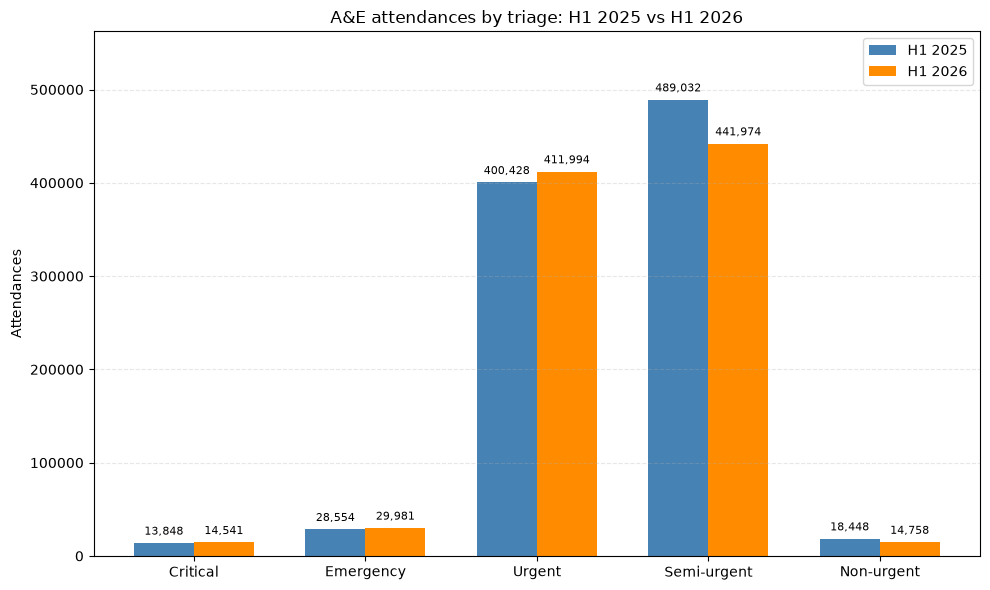

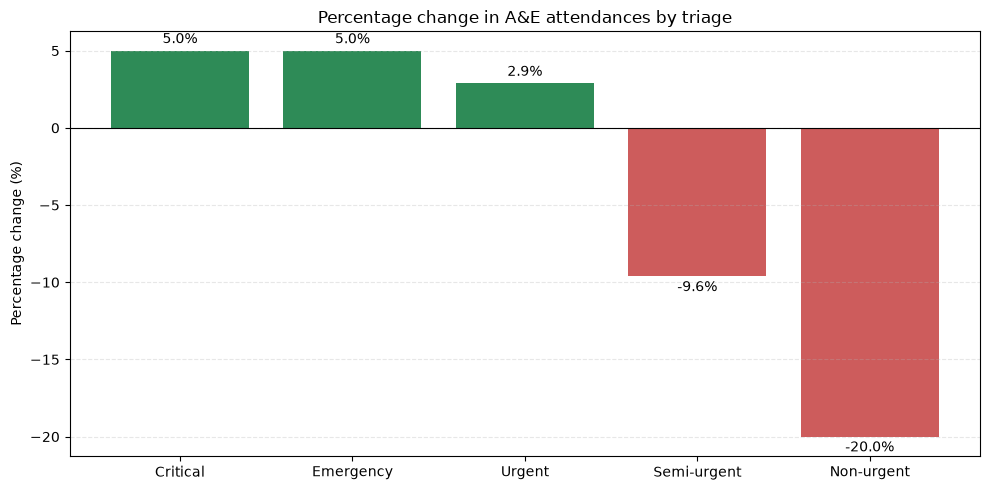

In [7]:
# Task 2 — write your own IPO prompt in the comments, then use Inline Chat
#
# Input: df (triage, triage_name, attend_h1_2025, attend_h1_2026)
# Process: calculate percentage change, build a grouped bar chart with attendance labels, and create a separate chart for percentage change
# Output: grouped bar chart with 10 bars and attendance labels; separate percentage-change chart

# Sort by triage order so the groups appear in the expected sequence.
plot_df = df.sort_values("triage").copy()

# Add percentage change for each triage group for the separate chart.
plot_df["pct_change"] = (
    (plot_df["attend_h1_2026"] - plot_df["attend_h1_2025"]) /
    plot_df["attend_h1_2025"]
) * 100

# Use a grouped bar plot with two bars per triage category.
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(plot_df))
bar_width = 0.35

bars_2025 = ax.bar(
    [i - bar_width / 2 for i in x],
    plot_df["attend_h1_2025"],
    width=bar_width,
    color="steelblue",
    label="H1 2025"
)

bars_2026 = ax.bar(
    [i + bar_width / 2 for i in x],
    plot_df["attend_h1_2026"],
    width=bar_width,
    color="darkorange",
    label="H1 2026"
)

# Put triage names on the x-axis.
ax.set_xticks(list(x))
ax.set_xticklabels(plot_df["triage_name"], rotation=0)

ax.set_ylabel("Attendances")
ax.set_title("A&E attendances by triage: H1 2025 vs H1 2026")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

# Add the actual attendance numbers above each bar.
for i, row in enumerate(plot_df.itertuples(index=False)):
    ax.annotate(
        f"{row.attend_h1_2025:,}",
        (i - bar_width / 2, row.attend_h1_2025),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8,
    )
    ax.annotate(
        f"{row.attend_h1_2026:,}",
        (i + bar_width / 2, row.attend_h1_2026),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8,
    )

ax.set_ylim(0, plot_df[["attend_h1_2025", "attend_h1_2026"]].to_numpy().max() * 1.15)
plt.tight_layout()
plt.show()

# Create a separate chart to compare percentage changes by triage.
fig, ax = plt.subplots(figsize=(10, 5))
percent_changes = plot_df["pct_change"]
bar_colors = ["seagreen" if value >= 0 else "indianred" for value in percent_changes]
bars_pct = ax.bar(plot_df["triage_name"], percent_changes, color=bar_colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.bar_label(bars_pct, labels=[f"{value:.1f}%" for value in percent_changes], padding=3)
ax.set_ylabel("Percentage change (%)")
ax.set_title("Percentage change in A&E attendances by triage")
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## Task 3 — Write-up

**Claim:** After fee reform, A&E improved — lower-urgency attendances fell; critical/emergency care stayed protected; urgent care became more efficient.

You may also cite: triage III within 30 min **81.4 → 88.5** (percentage); mean wait **23 → 20** min.

**3a** — Write **one supporting point** (cite a number) and **one gap** in the evidence.

**3b** — 2–4 sentences: how well is the claim supported by the published evidence (your table / chart, and any figures cited above)?


In [6]:
# Task 3
task3a = """
3a SUPPORT (1 point, cite a number):
The published evidence supports the claim that urgent care improved: 
triage III within 30 minutes rose from 81.4% to 88.5% after reform.

3a GAP (1 point):
A key gap is that the data do not show whether these changes were 
caused by fee reform rather than by broader demand, case-mix, or 
service changes over the same period.
"""

task3b = """
3b:
The claim is partly supported by the published evidence. 
Lower-urgency attendances fell in the triage data, with triage 4+5 combined down 10.0% 
and the most marked decline in non-urgent care (-20.0%), while triage 1–2 rose by 
about 5.0%, suggesting critical and emergency care stayed protected. The additional 
figures on triage III within 30 minutes (81.4% to 88.5%) and mean wait time (23 to 20 minutes) 
also support improved emergency performance. 
However, the evidence is still limited because it does not isolate the effect of fee reform 
from other changes in patient demand or hospital operations.
"""

print(task3a)
print("---")
print(task3b)




3a SUPPORT (1 point, cite a number):
The published evidence supports the claim that urgent care improved: 
triage III within 30 minutes rose from 81.4% to 88.5% after reform.

3a GAP (1 point):
A key gap is that the data do not show whether these changes were 
caused by fee reform rather than by broader demand, case-mix, or 
service changes over the same period.

---

3b:
The claim is partly supported by the published evidence. 
Lower-urgency attendances fell in the triage data, with triage 4+5 combined down 10.0% 
and the most marked decline in non-urgent care (-20.0%), while triage 1–2 rose by 
about 5.0%, suggesting critical and emergency care stayed protected. The additional 
figures on triage III within 30 minutes (81.4% to 88.5%) and mean wait time (23 to 20 minutes) 
also support improved emergency performance. 
However, the evidence is still limited because it does not isolate the effect of fee reform 
from other changes in patient demand or hospital operations.



## Submit

1. Save → Source Control → **Commit & Push**  
2. Moodle: paste your **GitHub URL**
